# DenseNet121 Amélioré — Chest X-Ray (NORMAL vs PNEUMONIA)

## Améliorations par rapport à la version précédente :
- ✅ **Bug normalisation corrigé** : utilisation de `preprocess_input` de DenseNet
- ✅ **Fine-tuning en 2 phases** : tête d'abord, puis backbone progressivement
- ✅ **val_dataset normalisé** avant évaluation
- ✅ **Monitoring sur val_auc** (plus robuste que val_loss avec déséquilibre)
- ✅ **Recherche du seuil optimal** pour maximiser F1 NORMAL
- ✅ **BatchNormalization + Dense(256)** dans la tête de classification


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt


## 1. Chemins

In [3]:
dataset_path = r"C:\Users\HP\Documents\IA\Stage\data\chest_xray\chest_xray"


## 2. Chargement des datasets

In [4]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "train"),
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "train"),
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


In [17]:
classes = ['NORMAL', 'PNEUMONIA']

for folder in ['train','val','test']:

    print(f"\n------ {folder} ------")

    for c in classes:

        path = os.path.join(dataset_path,folder,c)

        n = len(os.listdir(path))

        print(c,":",n)


------ train ------
NORMAL : 1342
PNEUMONIA : 3876

------ val ------
NORMAL : 9
PNEUMONIA : 9

------ test ------
NORMAL : 234
PNEUMONIA : 390


In [18]:
total = 0

for folder in ['train', 'val', 'test']:

    for c in classes:

        path = os.path.join(dataset_path, folder, c)

        total += len(os.listdir(path))

print("Nombre total d'images :", total)

Nombre total d'images : 5860


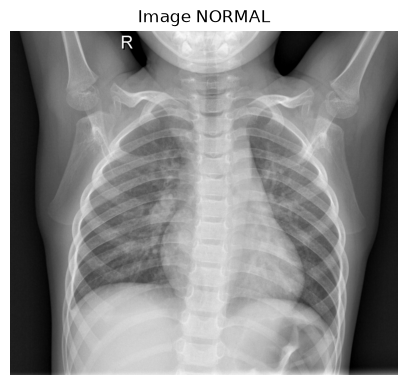

In [20]:
import os
from PIL import Image
import matplotlib.pyplot as plt

train_normal = r"C:\Users\HP\Documents\IA\Stage\data\chest_xray\chest_xray\train\NORMAL"

# Garder uniquement les fichiers images
image_files = [
    f for f in os.listdir(train_normal)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Choisir une image
image_name = image_files[0]

# Construire le chemin
image_path = os.path.join(train_normal, image_name)

# Ouvrir l'image
image = Image.open(image_path)

# Afficher
plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title("Image NORMAL")
plt.show()

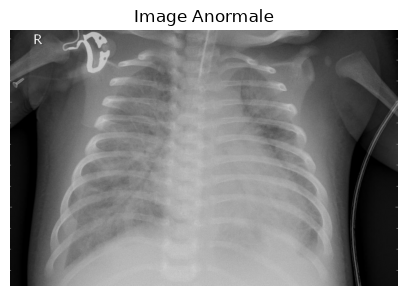

In [22]:
import os
from PIL import Image
import matplotlib.pyplot as plt

train_normal = r"C:\Users\HP\Documents\IA\Stage\data\chest_xray\chest_xray\train\PNEUMONIA"

# Garder uniquement les fichiers images
image_files = [
    f for f in os.listdir(train_normal)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Choisir une image
image_name = image_files[0]

# Construire le chemin
image_path = os.path.join(train_normal, image_name)

# Ouvrir l'image
image = Image.open(image_path)

# Afficher
plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title("Image Anormale")
plt.show()

## 3. Normalisation — CORRECTION DU BUG

> DenseNet121 a sa propre normalisation interne (`preprocess_input`).  
> Utiliser `Rescaling(1./255)` comme avant était **incorrect** pour ce backbone.

In [ ]:
def preprocess(image, label):
    image = tf.cast(image, tf.float32)#Cette ligne convertit les pixels de l'image en nombres de type float32.
    image = preprocess_input(image)  # normalisation correcte pour DenseNet121
    return image, label


## 4. Data Augmentation + Pipelines

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1),   # utile pour les radios
], name="data_augmentation")

def augment_and_preprocess(image, label):
    image = data_augmentation(image, training=True)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

# Pipelines optimisés
augmented_train = (
    train_dataset
    .map(augment_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(500)
    .prefetch(tf.data.AUTOTUNE)
)

normalized_val = (
    val_dataset
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

normalized_test = (
    test_dataset
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)


## 5. Class Weights (gérer le déséquilibre NORMAL vs PNEUMONIA)

In [7]:
train_labels = np.concatenate([y.numpy() for x, y in train_dataset])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weights)
# → {0: ~1.91 (NORMAL est sous-représenté), 1: ~0.68 (PNEUMONIA)}


Class weights: {0: np.float64(1.9107142857142858), 1: np.float64(0.6772151898734177)}


                    ┌──────────────────┐
Image 224×224×3 ───→│   DenseNet121    │
                    │     frozen       │
                    └────────┬─────────┘
                             ↓
                  GlobalAveragePooling2D
                             ↓
                    BatchNormalization
                             ↓
                       Dense 256
                        + ReLU
                             ↓
                       Dropout 40%
                             ↓
                      Dense 1 + Sigmoid
                             ↓
                    NORMAL / PNEUMONIA

## 6. Construction du modèle

Tête améliorée : `GlobalAveragePooling → BatchNorm → Dense(256) → Dropout(0.4) → Dense(1)`

In [8]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # gelé pour la Phase 1
print(f"Backbone : {base_model.count_params():,} paramètres (gelés)")

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)        # ajouté pour stabiliser
x = layers.Dense(256, activation="relu")(x)  # couche plus riche
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)
model.summary()


Backbone : 7,037,504 paramètres (gelés)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,304,257 (27.86 MB)

 Trainable params: 264,705 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

## 7. Fonction de compilation

In [9]:
def compile_model(lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

compile_model(lr=1e-4)


## 8–9. Phase 1 : Entraîner uniquement la tête (backbone gelé)

> Objectif : que la tête apprenne les features de base avant le fine-tuning  
          

In [10]:
callbacks_phase1 = [
    EarlyStopping(
        monitor="val_auc", patience=5,
        restore_best_weights=True, mode="max", verbose=1
    ),
    ModelCheckpoint(
        "best_densenet121_phase1.keras",
        monitor="val_auc", save_best_only=True, mode="max", verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.3,
        patience=3, min_lr=1e-7, verbose=1
    ),
]

print("========== PHASE 1 : Entraînement de la tête ==========")
history1 = model.fit(
    augmented_train,
    validation_data=normalized_val,   # ← val normalisé (corrigé)
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks_phase1
)


========== PHASE 1 : Entraînement de la tête ==========
Epoch 1/15


c:\Users\HP\Documents\IA\ANN\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8081 - auc: 0.9335 - loss: 0.3543 - precision: 0.9676 - recall: 0.7657
Epoch 1: val_auc improved from None to 0.97642, saving model to best_densenet121_phase1.keras

Epoch 1: finished saving model to best_densenet121_phase1.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 550s 4s/step - accuracy: 0.8081 - auc: 0.9335 - loss: 0.3543 - precision: 0.9676 - recall: 0.7657 - val_accuracy: 0.9147 - val_auc: 0.9764 - val_loss: 0.2529 - val_precision: 0.9796 - val_recall: 0.9068 - learning_rate: 1.0000e-04
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9133 - auc: 0.9760 - loss: 0.2038 - precision: 0.9795 - recall: 0.9013
Epoch 2: val_auc improved from 0.97642 to 0.98503, saving model to best_densenet121_phase1.keras

Epoch 2: finished saving model to best_densenet121_phase1.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 569s 4s/step - accuracy: 0.9133 - auc: 0.9760 - loss: 0.2038 - precision: 0.9795 - recall: 0.9013 - val_accuracy: 0.9281 - val_au

Le learning rate (taux d'apprentissage) détermine la taille des modifications apportées aux poids du modèle à chaque étape d'apprentissage.

## 10. Phase 2 : Fine-tuning des 50 dernières couches du backbone

> LR beaucoup plus faible (`1e-5`) pour ne pas détruire les poids ImageNet

In [11]:
base_model.trainable = True

# Geler tout SAUF les 50 dernières couches
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Couches dégelées : {trainable_count} / {len(base_model.layers)}")

compile_model(lr=1e-5)  # LR 10x plus petit qu'en phase 1

callbacks_phase2 = [
    EarlyStopping(
        monitor="val_auc", patience=7,
        restore_best_weights=True, mode="max", verbose=1
    ),
    ModelCheckpoint(
        "best_densenet121_phase2.keras",
        monitor="val_auc", save_best_only=True, mode="max", verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.3,
        patience=3, min_lr=1e-8, verbose=1
    ),
]

print("========== PHASE 2 : Fine-tuning ==========")
history2 = model.fit(
    augmented_train,
    validation_data=normalized_val,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_phase2
)


Couches dégelées : 50 / 427
========== PHASE 2 : Fine-tuning ==========
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9573 - auc: 0.9923 - loss: 0.1100 - precision: 0.9869 - recall: 0.9549
Epoch 1: val_auc improved from None to 0.99273, saving model to best_densenet121_phase2.keras

Epoch 1: finished saving model to best_densenet121_phase2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 572s 4s/step - accuracy: 0.9573 - auc: 0.9923 - loss: 0.1100 - precision: 0.9869 - recall: 0.9549 - val_accuracy: 0.9453 - val_auc: 0.9927 - val_loss: 0.1427 - val_precision: 0.9920 - val_recall: 0.9358 - learning_rate: 1.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9549 - auc: 0.9928 - loss: 0.1069 - precision: 0.9865 - recall: 0.9520
Epoch 2: val_auc improved from 0.99273 to 0.99273, saving model to best_densenet121_phase2.keras

Epoch 2: finished saving model to best_densenet121_phase2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 532s 4s/step - accuracy: 0.9549 - auc: 0.9928 

## 11. Évaluation sur le test set

In [12]:
print("========== EVALUATION FINALE ==========")
test_results = model.evaluate(normalized_test, return_dict=True)
print(test_results)


========== EVALUATION FINALE ==========
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8958 - auc: 0.9651 - loss: 0.2719 - precision: 0.8842 - recall: 0.9590
{'accuracy': 0.8958333134651184, 'auc': 0.9651051163673401, 'loss': 0.2718806266784668, 'precision': 0.8841607570648193, 'recall': 0.9589743614196777}


## 12. Recherche du seuil optimal

> Le seuil par défaut (0.5) n'est pas optimal quand les classes sont déséquilibrées.
> On cherche le seuil qui maximise le F1-score de la classe NORMAL (souvent mal classifiée).

In [13]:
y_true = np.concatenate([y.numpy() for x, y in test_dataset])
y_prob = model.predict(normalized_test).ravel()

best_threshold = 0.5
best_f1_normal = 0

print("--- Recherche du seuil optimal ---")
for threshold in np.arange(0.25, 0.76, 0.05):
    y_pred = (y_prob >= threshold).astype(int)
    f1_normal    = f1_score(y_true, y_pred, pos_label=0)
    f1_pneumonia = f1_score(y_true, y_pred, pos_label=1)
    print(f"Seuil {threshold:.2f} | F1 NORMAL={f1_normal:.3f} | F1 PNEUMONIA={f1_pneumonia:.3f}")
    if f1_normal > best_f1_normal:
        best_f1_normal = f1_normal
        best_threshold = threshold

print(f"\n✅ Meilleur seuil : {best_threshold:.2f}")

y_pred_final = (y_prob >= best_threshold).astype(int)
print("\n--- Classification Report Final ---")
print(classification_report(y_true, y_pred_final, target_names=["NORMAL", "PNEUMONIA"]))

cm = confusion_matrix(y_true, y_pred_final)
print("Matrice de confusion :")
print(cm)


20/20 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step
--- Recherche du seuil optimal ---
Seuil 0.25 | F1 NORMAL=0.761 | F1 PNEUMONIA=0.892
Seuil 0.30 | F1 NORMAL=0.786 | F1 PNEUMONIA=0.900
Seuil 0.35 | F1 NORMAL=0.816 | F1 PNEUMONIA=0.911
Seuil 0.40 | F1 NORMAL=0.838 | F1 PNEUMONIA=0.918
Seuil 0.45 | F1 NORMAL=0.844 | F1 PNEUMONIA=0.918
Seuil 0.50 | F1 NORMAL=0.851 | F1 PNEUMONIA=0.920
Seuil 0.55 | F1 NORMAL=0.858 | F1 PNEUMONIA=0.922
Seuil 0.60 | F1 NORMAL=0.862 | F1 PNEUMONIA=0.922
Seuil 0.65 | F1 NORMAL=0.873 | F1 PNEUMONIA=0.927
Seuil 0.70 | F1 NORMAL=0.883 | F1 PNEUMONIA=0.931
Seuil 0.75 | F1 NORMAL=0.885 | F1 PNEUMONIA=0.931

✅ Meilleur seuil : 0.75

--- Classification Report Final ---
              precision    recall  f1-score   support

      NORMAL       0.88      0.88      0.88       234
   PNEUMONIA       0.93      0.93      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.91      0.91       624
weighted avg       0.91      0.91      0.9

## 13. Courbes d'apprentissage (Phase 1 + Phase 2)

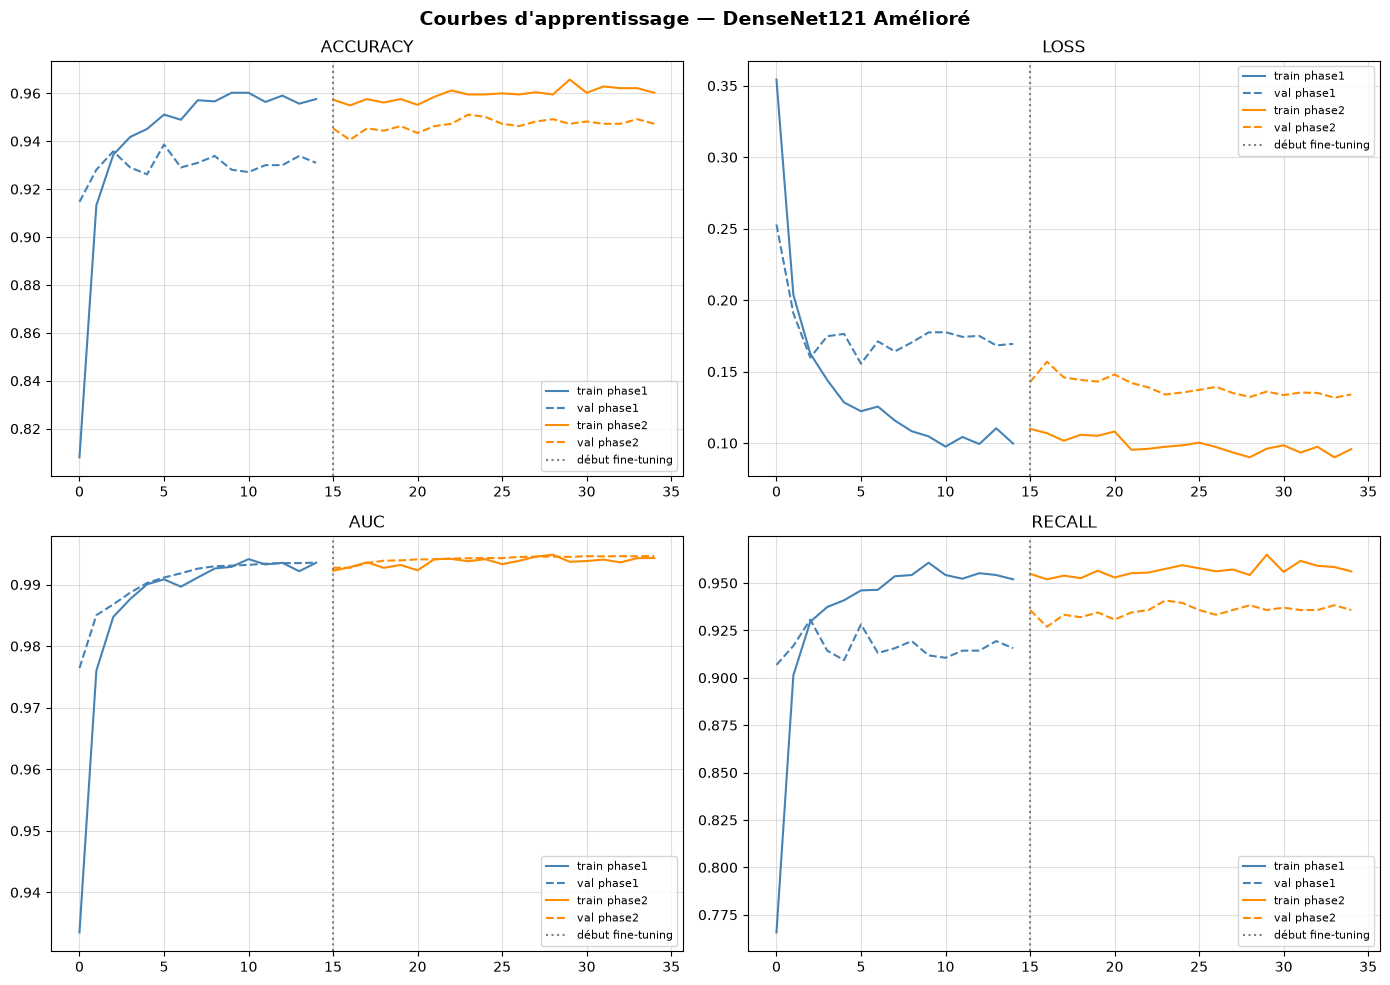

Graphique sauvegardé : courbes_apprentissage.png


In [14]:
def plot_history(h1, h2):
    metrics = ["accuracy", "loss", "auc", "recall"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    offset = len(h1.history["loss"])

    for i, metric in enumerate(metrics):
        axes[i].plot(h1.history[metric], label="train phase1", color="steelblue")
        axes[i].plot(h1.history[f"val_{metric}"], label="val phase1",
                     color="steelblue", linestyle="--")
        ep2 = range(offset, offset + len(h2.history[metric]))
        axes[i].plot(ep2, h2.history[metric], label="train phase2", color="darkorange")
        axes[i].plot(ep2, h2.history[f"val_{metric}"], label="val phase2",
                     color="darkorange", linestyle="--")
        axes[i].axvline(x=offset, color="gray", linestyle=":", label="début fine-tuning")
        axes[i].set_title(metric.upper(), fontsize=12)
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.4)

    plt.suptitle("Courbes d'apprentissage — DenseNet121 Amélioré", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("courbes_apprentissage.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Graphique sauvegardé : courbes_apprentissage.png")

plot_history(history1, history2)


In [15]:


print("Dossier de travail actuel :")
print(os.getcwd())

Dossier de travail actuel :
c:\Users\HP\Downloads
